<a href="https://colab.research.google.com/github/ERAEstudianteUB2026/UBPhD-Machine-Learning2026/blob/main/MLActividad_clase_S4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Cargar datos desde el computador
from google.colab import files
import pandas as pd

uploaded = files.upload()

Saving Dry_Bean_Dataset.xlsx to Dry_Bean_Dataset.xlsx


In [ ]:
df = pd.read_excel("Dry_Bean_Dataset.xlsx")

df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


## Exploración inicial

In [ ]:
# Dimensiones
print("Dimensiones:", df.shape)

# Primeras observaciones
display(df.head())

# Información general
df.info()

Dimensiones: (13611, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

## Estadísticas Descriptivas

In [ ]:
# Función para estadísticas descriptivas
def Descriptivas(df):

    # Eliminar variable cualitativa
    datos = df.drop(columns=["Class"])

    resultados = []

    # Recorrer las variables cuantitativas
    for variable in datos.columns:

        media = datos[variable].mean()
        mediana = datos[variable].median()
        desviacion = datos[variable].std()
        minimo = datos[variable].min()
        maximo = datos[variable].max()
        cv = desviacion / media

        resultados.append([
            variable,
            media,
            mediana,
            desviacion,
            minimo,
            maximo,
            cv
        ])

    # Crear DataFrame al terminar el ciclo
    resultados_df = pd.DataFrame(
        resultados,
        columns=[
            "Variable",
            "Media",
            "Mediana",
            "Desviación estándar",
            "Mínimo",
            "Máximo",
            "Coeficiente de variación"
        ]
    )

    return resultados_df


In [ ]:
resultados=Descriptivas(df)
resultados

,Variable,Media,Mediana,Desviación estándar,Mínimo,Máximo,Coeficiente de variación
0,Area,53048.284549,44652.000000,29324.095717,20420.000000,254616.000000,0.552781
1,Perimeter,855.283459,794.941000,214.289696,524.736000,1985.370000,0.250548
2,MajorAxisLength,320.141867,296.883367,85.694186,183.601165,738.860153,0.267676
3,MinorAxisLength,202.270714,192.431733,44.970091,122.512653,460.198497,0.222326
4,AspectRation,1.583242,1.551124,0.246678,1.024868,2.430306,0.155806
5,Eccentricity,0.750895,0.764441,0.092002,0.218951,0.911423,0.122523
6,ConvexArea,53768.200206,45178.000000,29774.915817,20684.000000,263261.000000,0.553764
7,EquivDiameter,253.064220,238.438026,59.177120,161.243764,569.374358,0.233842
8,Extent,0.749733,0.759859,0.049086,0.555315,0.866195,0.065472
9,Solidity,0.987143,0.988283,0.004660,0.919246,0.994677,0.004721


### Gráficos

In [ ]:
def Gráficos(df):
  datos = df.drop(columns=["Class"])
  for i in datos.columns:
    plt.hist(datos[i])
    plt.title(i)
    plt.show()

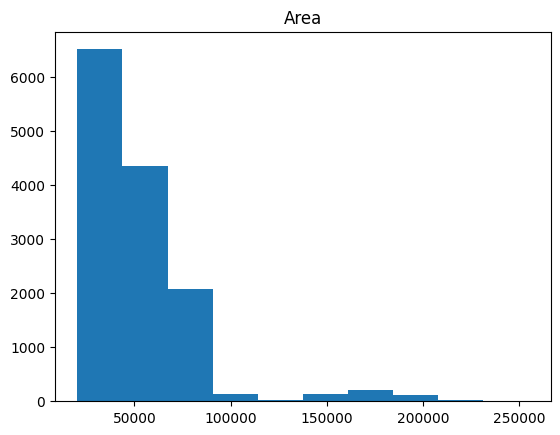

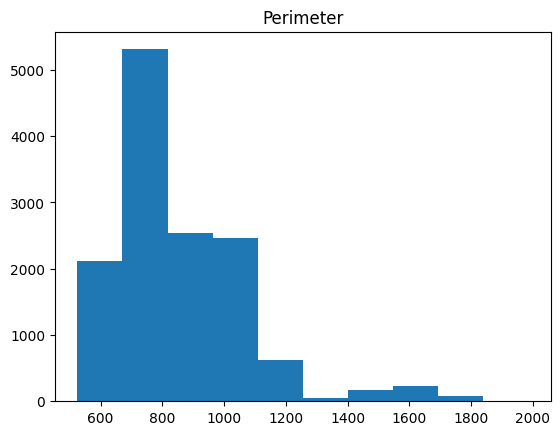

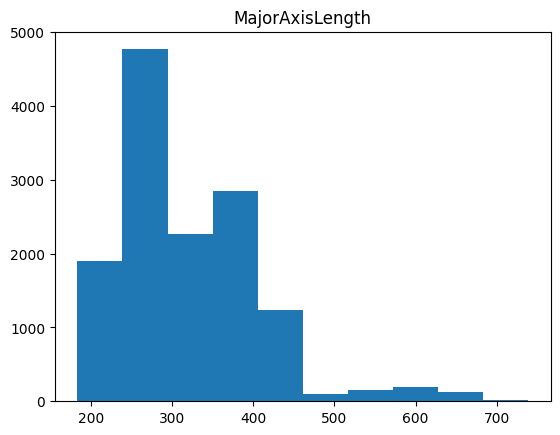

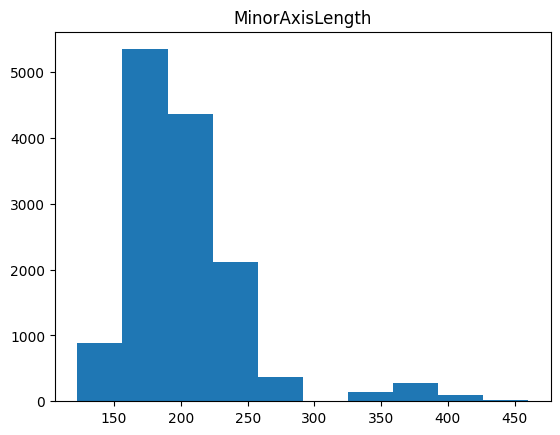

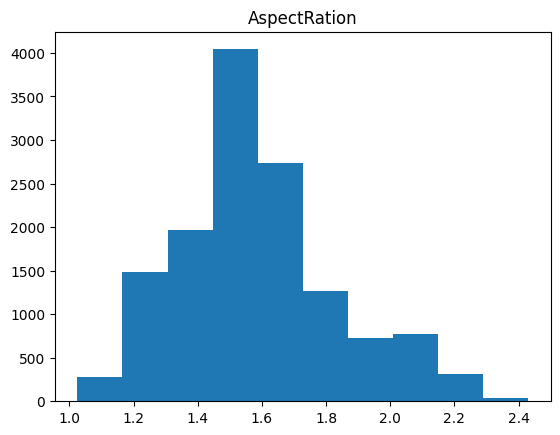

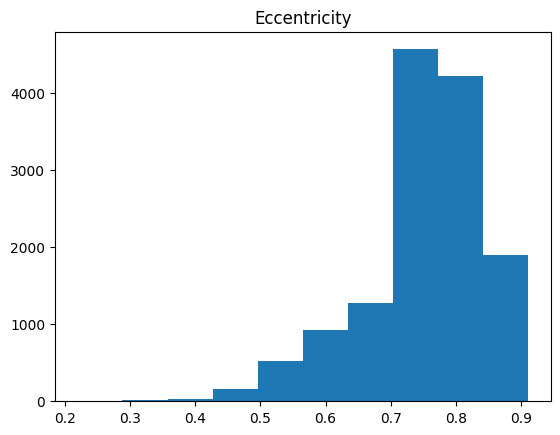

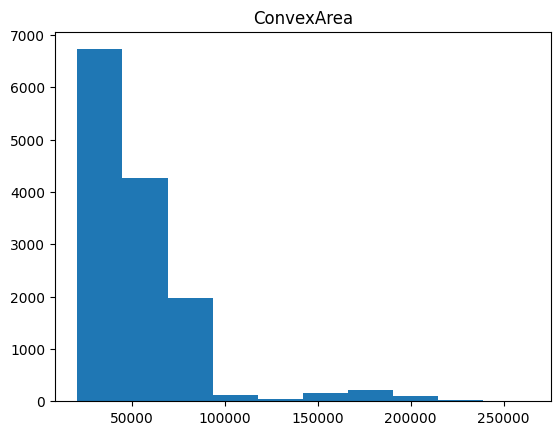

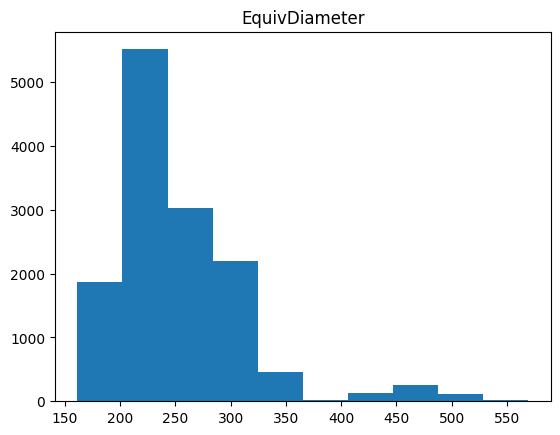

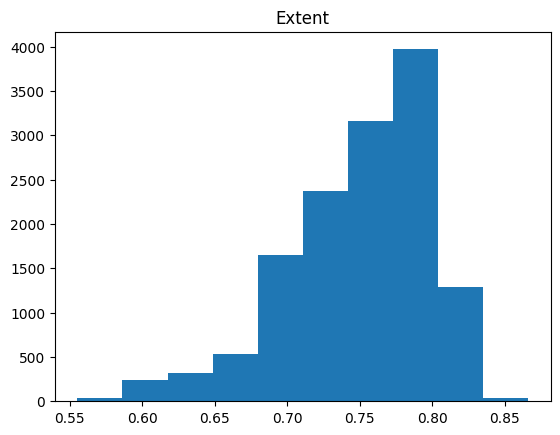

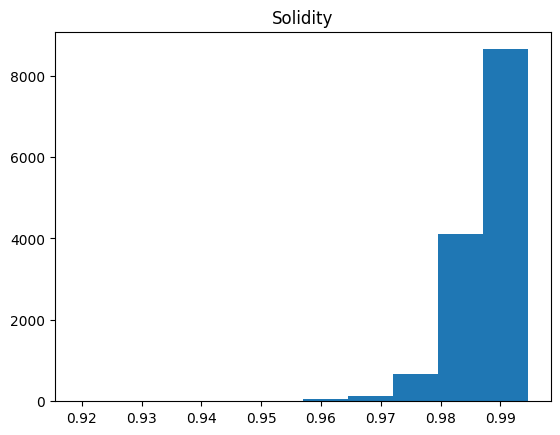

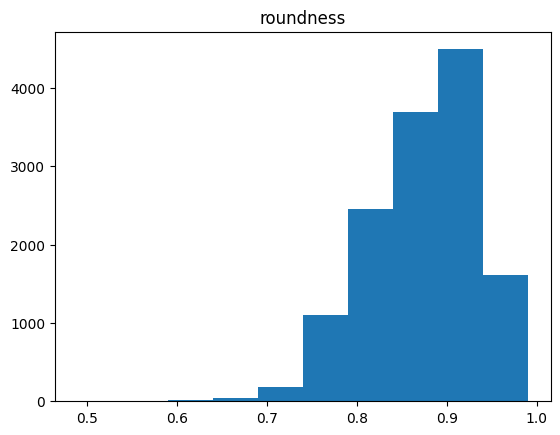

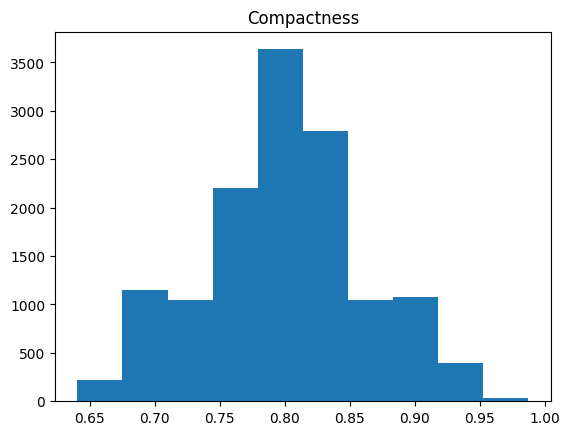

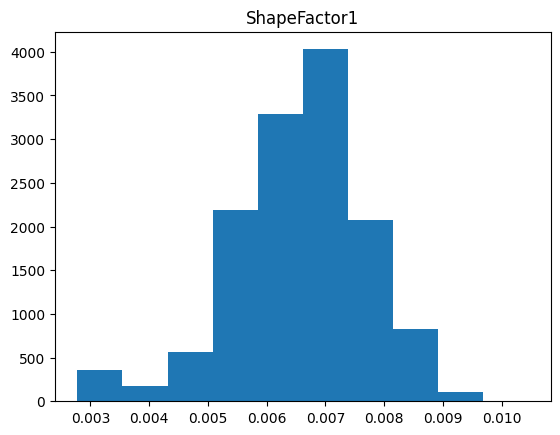

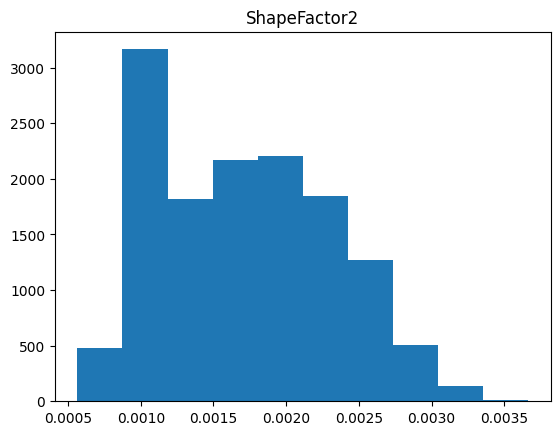

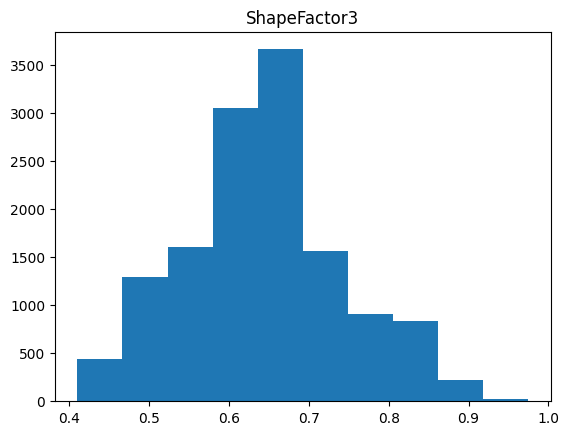

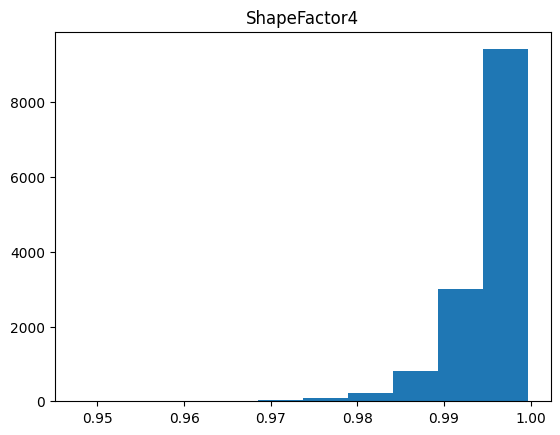

In [ ]:
Gráficos(df)

## Valores faltantes y duplicados

In [ ]:
# Valores faltantes
print("Valores faltantes:")
print(df.isnull().sum())

# Datos duplicados
print("\nNúmero de filas duplicadas:")
print(df.duplicated().sum())

Valores faltantes:
Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

Número de filas duplicadas:
68


In [ ]:
#Eliminar datos duplicados

print("Dimensión antes:", df.shape)

df = df.drop_duplicates().reset_index(drop=True)

print("Dimensión después:", df.shape)
print("Duplicados restantes:", df.duplicated().sum())

Dimensión antes: (13611, 17)
Dimensión después: (13543, 17)
Duplicados restantes: 0


## Boxplot para valores extremos

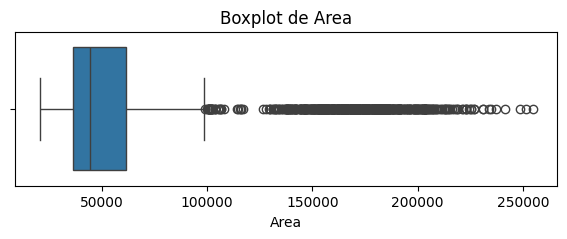

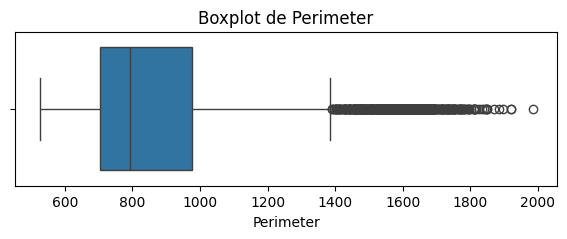

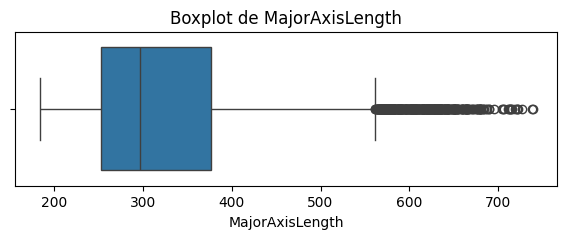

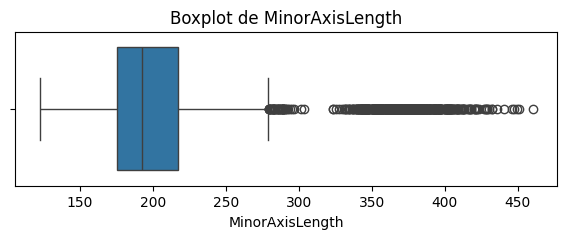

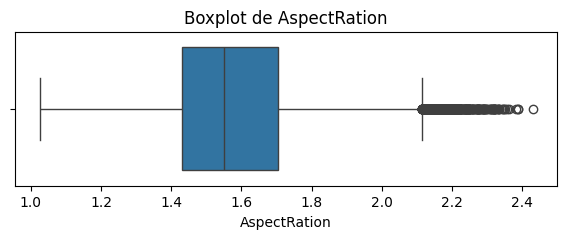

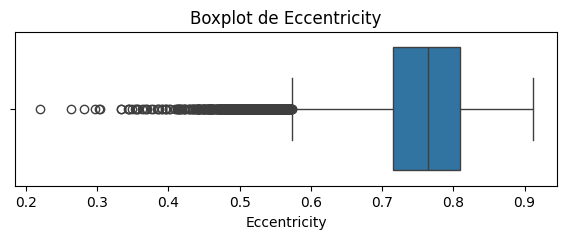

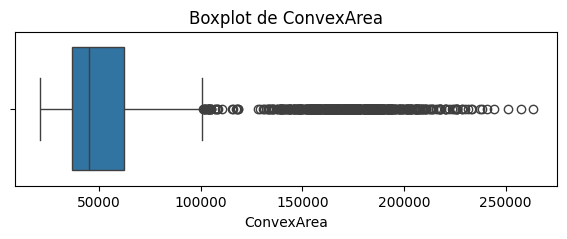

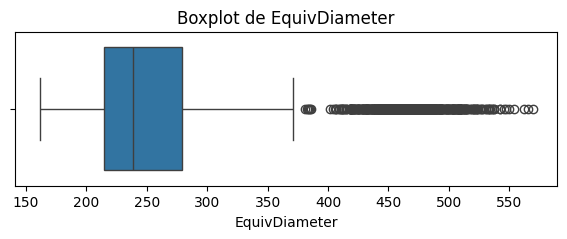

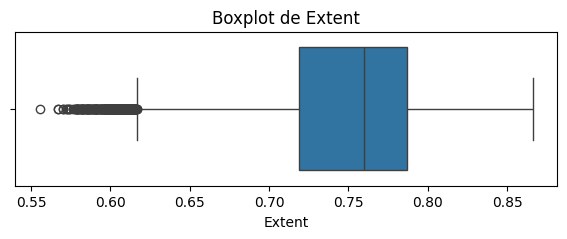

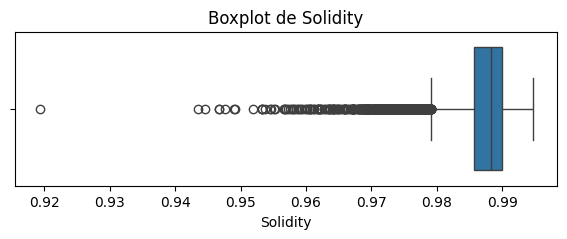

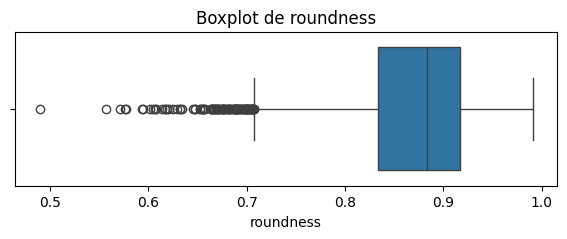

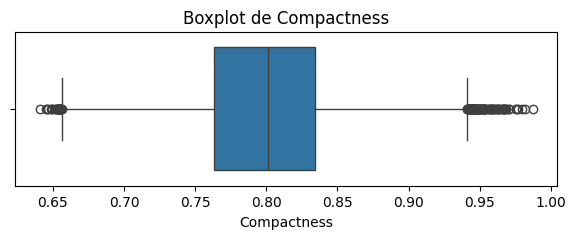

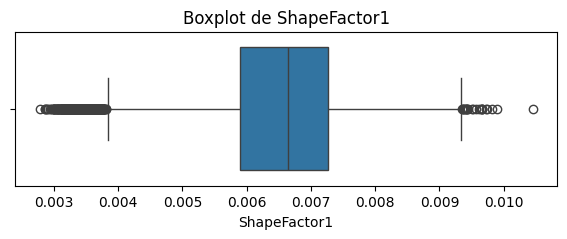

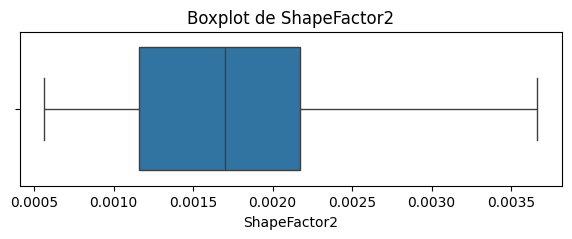

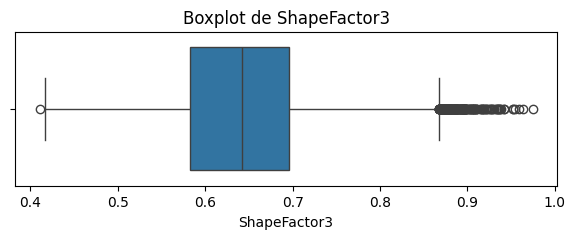

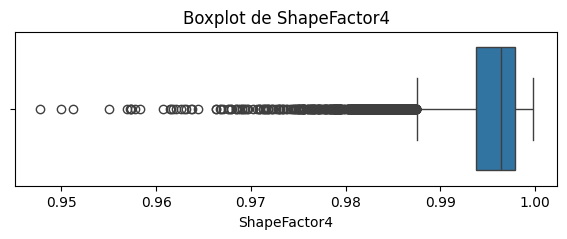

In [ ]:
# ============================================================
# BOXPLOTS
# ============================================================

def Boxplots(df):

    datos = df.drop(columns=["Class"])

    for variable in datos.columns:

        plt.figure(figsize=(7, 2))

        sns.boxplot(x=datos[variable])

        plt.title(f"Boxplot de {variable}")
        plt.xlabel(variable)

        plt.show()


Boxplots(df)

## Mtriz de correlación

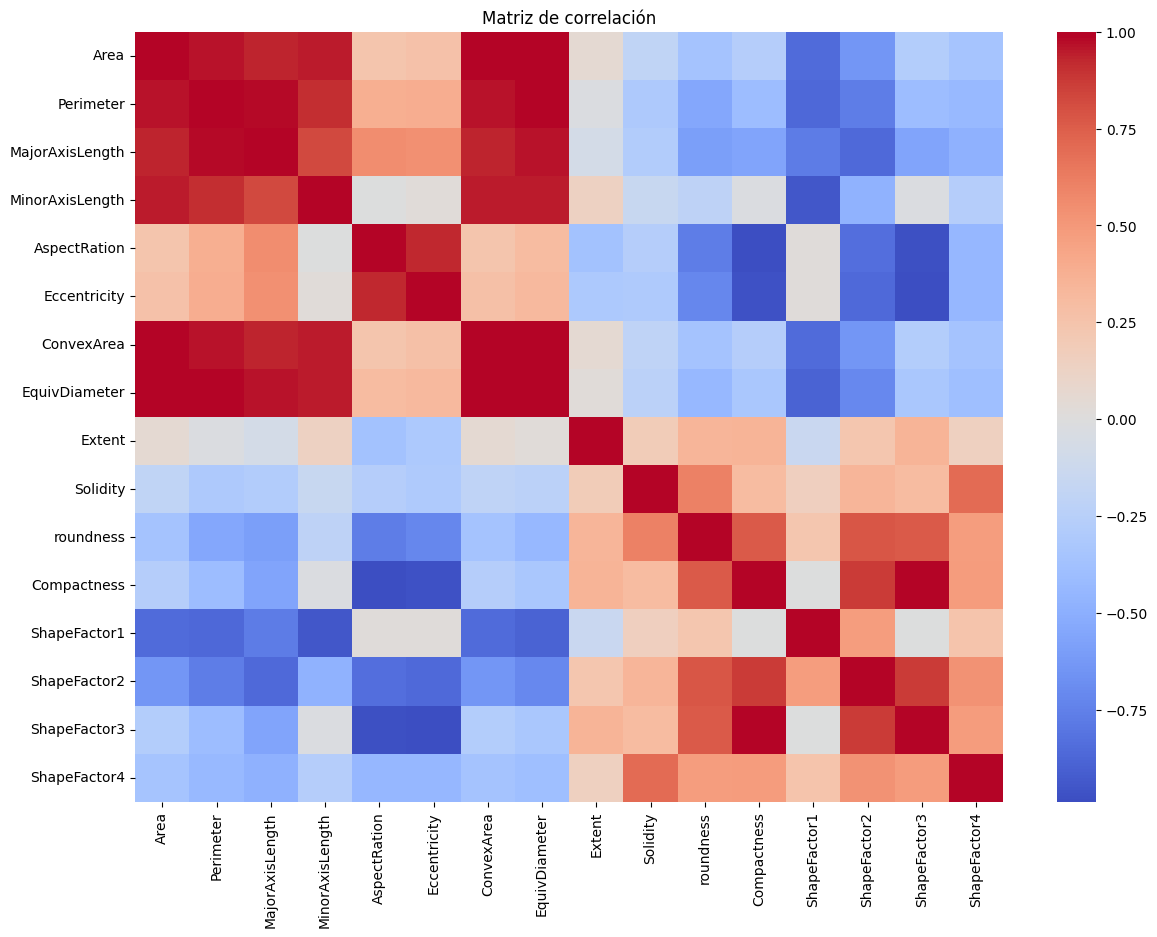

In [ ]:
datos_num = df.drop(columns=["Class"])

matriz_corr = datos_num.corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    matriz_corr,
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("Matriz de correlación")

plt.show()

In [ ]:
#Ver la correlaciones más fuertes

corr = matriz_corr.abs()

pares = (
    corr.where(
        np.triu(np.ones(corr.shape), k=1).astype(bool)
    )
    .stack()
    .sort_values(ascending=False)
)

pares.head(15)

,,0
Area,ConvexArea,0.999940
Compactness,ShapeFactor3,0.998684
Perimeter,EquivDiameter,0.991453
AspectRation,Compactness,0.987644
ConvexArea,EquivDiameter,0.985255
Area,EquivDiameter,0.984998
Eccentricity,ShapeFactor3,0.981058
AspectRation,ShapeFactor3,0.978528
Perimeter,MajorAxisLength,0.977561
Eccentricity,Compactness,0.970308


## Kmenas con dos variables

seleccionamos solo dos variabeles:



In [ ]:
# SELECCIÓN DE VARIABLES
X = df[["Area", "roundness"]].copy()

X.head()

,Area,roundness
0,28395,0.958027
1,28734,0.887034
2,29380,0.947849
3,30008,0.903936
4,30140,0.984877


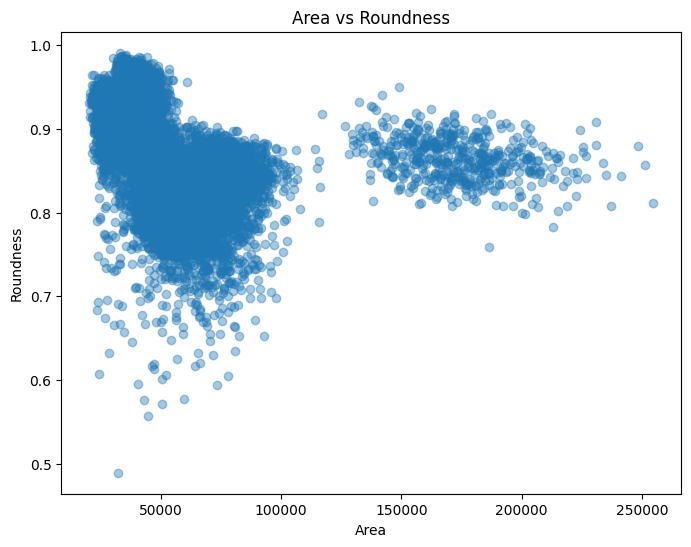

In [ ]:
# GRÁFICO DE LAS VARIABLES ORIGINALES

plt.figure(figsize=(8, 6))

plt.scatter(
    X["Area"],
    X["roundness"],
    alpha=0.4
)

plt.xlabel("Area")
plt.ylabel("Roundness")
plt.title("Area vs Roundness")

plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

# Seleccionar variables
X = df[["Area", "roundness"]].copy()

# Crear escalador
scaler = StandardScaler()

# Ajustar y transformar
X_scaled = scaler.fit_transform(X)

In [ ]:
X_scaled = pd.DataFrame(
    X_scaled,
    columns=["Area", "roundness"]
)

X_scaled.head()

,Area,roundness
0,-0.838800,1.420346
1,-0.827266,0.224987
2,-0.805287,1.248979
3,-0.783920,0.509588
4,-0.779429,1.872434


## Aplicamos el modelo

In [ ]:
from sklearn.cluster import KMeans

inercias = []

K = range(2, 11)

for k in K:

    kmeans = KMeans(
        n_clusters=k,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inercias.append(kmeans.inertia_)

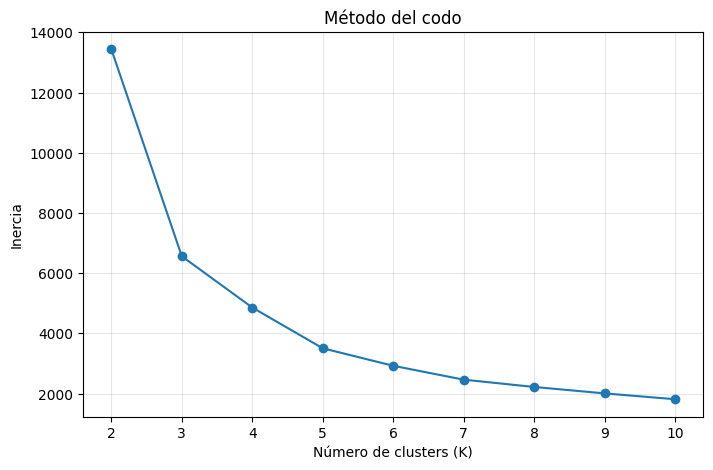

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(K, inercias, marker="o")

plt.xlabel("Número de clusters (K)")
plt.ylabel("Inercia")
plt.title("Método del codo")

plt.xticks(K)
plt.grid(alpha=0.3)

plt.show()

In [ ]:
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

resultados_k = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    clusters = kmeans.fit_predict(X_scaled)

    silhouette = silhouette_score(X_scaled, clusters)
    davies = davies_bouldin_score(X_scaled, clusters)
    calinski = calinski_harabasz_score(X_scaled, clusters)

    resultados_k.append([
        k,
        silhouette,
        davies,
        calinski
    ])

In [ ]:
metricas = pd.DataFrame(
    resultados_k,
    columns=[
        "K",
        "Silhouette",
        "Davies-Bouldin",
        "Calinski-Harabasz"
    ]
)

metricas

,K,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,2,0.539799,0.767354,13751.471930
1,3,0.579720,0.558212,21181.149729
2,4,0.483869,0.751448,20656.342245
3,5,0.433074,0.739066,22787.874167
4,6,0.431290,0.778965,22393.080429
5,7,0.414747,0.777659,22578.659509
6,8,0.401952,0.815978,21684.396321
7,9,0.391991,0.883364,21107.583728
8,10,0.384400,0.854963,20980.147428


In [ ]:
metricas = pd.DataFrame(
    resultados_k,
    columns=[
        "K",
        "Silhouette",
        "Davies-Bouldin",
        "Calinski-Harabasz"
    ]
)

metricas

,K,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,2,0.539799,0.767354,13751.471930
1,3,0.579720,0.558212,21181.149729
2,4,0.483869,0.751448,20656.342245
3,5,0.433074,0.739066,22787.874167
4,6,0.431290,0.778965,22393.080429
5,7,0.414747,0.777659,22578.659509
6,8,0.401952,0.815978,21684.396321
7,9,0.391991,0.883364,21107.583728
8,10,0.384400,0.854963,20980.147428


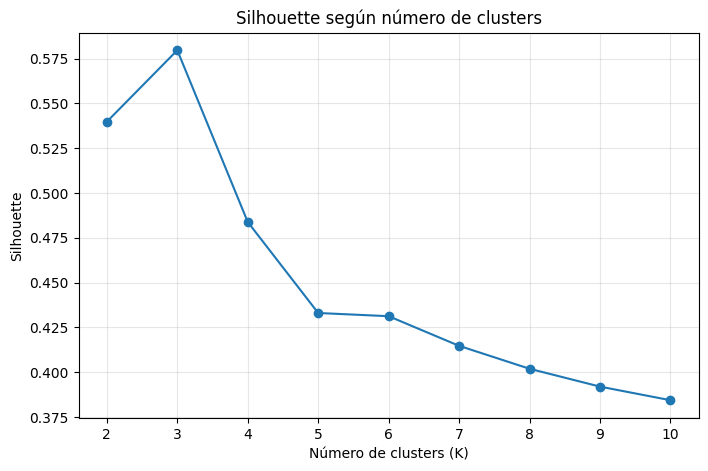

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    metricas["K"],
    metricas["Silhouette"],
    marker="o"
)

plt.xlabel("Número de clusters (K)")
plt.ylabel("Silhouette")
plt.title("Silhouette según número de clusters")
plt.xticks(metricas["K"])
plt.grid(alpha=0.3)

plt.show()

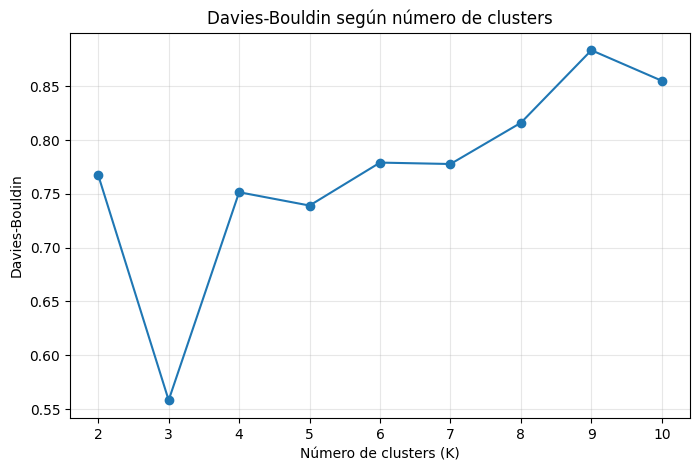

In [ ]:
## Graficar méticas

plt.figure(figsize=(8,5))

plt.plot(
    metricas["K"],
    metricas["Davies-Bouldin"],
    marker="o"
)

plt.xlabel("Número de clusters (K)")
plt.ylabel("Davies-Bouldin")
plt.title("Davies-Bouldin según número de clusters")
plt.xticks(metricas["K"])
plt.grid(alpha=0.3)

plt.show()

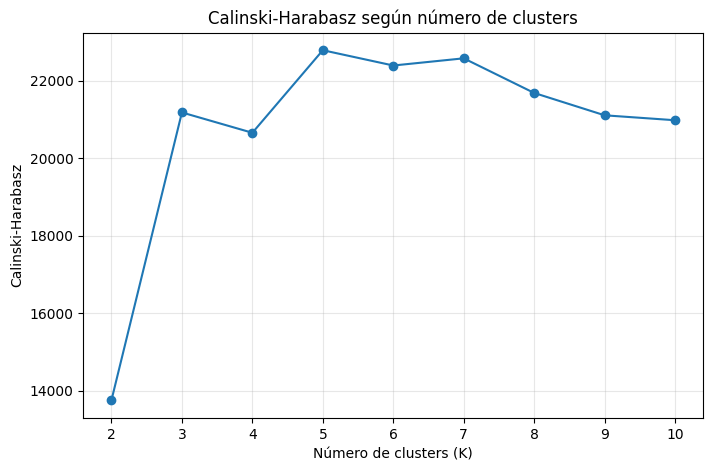

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    metricas["K"],
    metricas["Calinski-Harabasz"],
    marker="o"
)

plt.xlabel("Número de clusters (K)")
plt.ylabel("Calinski-Harabasz")
plt.title("Calinski-Harabasz según número de clusters")
plt.xticks(metricas["K"])
plt.grid(alpha=0.3)

plt.show()

In [ ]:
print(
    "Silhouette:",
    metricas.loc[metricas["Silhouette"].idxmax(), ["K", "Silhouette"]]
)

print(
    "\nDavies-Bouldin:",
    metricas.loc[metricas["Davies-Bouldin"].idxmin(), ["K", "Davies-Bouldin"]]
)

print(
    "\nCalinski-Harabasz:",
    metricas.loc[metricas["Calinski-Harabasz"].idxmax(), ["K", "Calinski-Harabasz"]]
)

Silhouette: K             3.00000
Silhouette    0.57972
Name: 1, dtype: float64

Davies-Bouldin: K                 3.000000
Davies-Bouldin    0.558212
Name: 1, dtype: float64

Calinski-Harabasz: K                        5.000000
Calinski-Harabasz    22787.874167
Name: 3, dtype: float64


## Kmeans final

In [ ]:
# MODELO K-MEANS FINAL


kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

In [ ]:
X_resultados = X.copy()

X_resultados["Cluster"] = clusters

X_resultados.head()

,Area,roundness,Cluster
0,28395,0.958027,0
1,28734,0.887034,0
2,29380,0.947849,0
3,30008,0.903936,0
4,30140,0.984877,0


In [ ]:
# Observacioens por clusterinr

In [ ]:
X_resultados["Cluster"].value_counts().sort_index()

,count
Cluster,
0,7948
1,5074
2,521


In [ ]:
# Centroides
centroides_scaled = kmeans.cluster_centers_

centroides_scaled

array([[-0.50693646,  0.67101356],
       [ 0.37223   , -1.03371386],
       [ 4.10157251, -0.1561089 ]])

In [ ]:
# Unidades originales
centroides = scaler.inverse_transform(
    kmeans.cluster_centers_
)

centroides_df = pd.DataFrame(
    centroides,
    columns=["Area", "roundness"]
)

centroides_df

,Area,roundness
0,38148.911883,0.913524
1,63988.803860,0.812278
2,173599.226488,0.864400


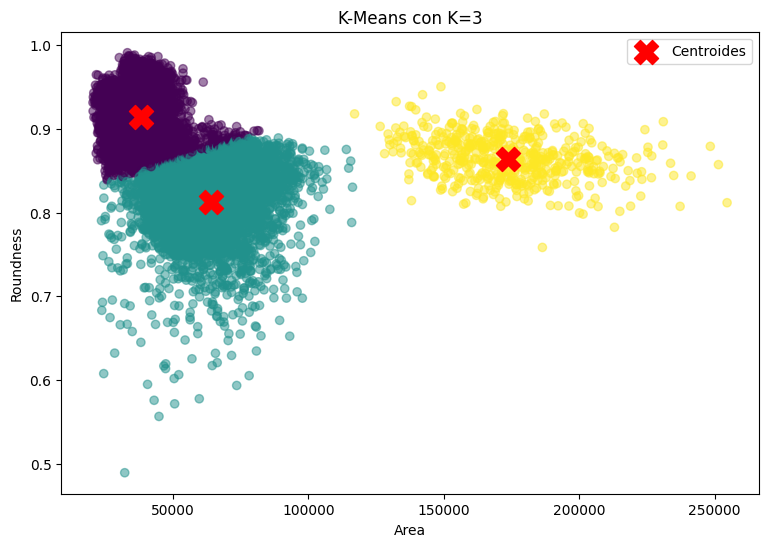

In [ ]:
# Gráfico de clusteirn

plt.figure(figsize=(9, 6))

plt.scatter(
    X_resultados["Area"],
    X_resultados["roundness"],
    c=X_resultados["Cluster"],
    cmap="viridis",
    alpha=0.5
)

# Centroides
plt.scatter(
    centroides_df["Area"],
    centroides_df["roundness"],
    marker="X",
    s=300,
    c="red",
    label="Centroides"
)

plt.xlabel("Area")
plt.ylabel("Roundness")
plt.title("K-Means con K=3")

plt.legend()
plt.show()

In [ ]:
### Perfilamos clustering
perfil_clusters = (
    X_resultados
    .groupby("Cluster")
    .agg(
        Area_media=("Area", "mean"),
        Area_mediana=("Area", "median"),
        Roundness_media=("roundness", "mean"),
        Roundness_mediana=("roundness", "median"),
        n=("Cluster", "size")
    )
)

perfil_clusters

,Area_media,Area_mediana,Roundness_media,Roundness_mediana,n
Cluster,,,,,
0,38153.174383,37996.5,0.913496,0.911549,7948
1,64002.497438,63778.0,0.812242,0.815608,5074
2,173599.226488,171566.0,0.864400,0.864723,521


### Interpretación de los clusters

| Cluster | Área media | Roundness media | Número de observaciones |
|---------|-----------:|---------------:|------------------------:|
| 0 | 38,153 | 0.9135 | 7,948 |
| 1 | 64,002 | 0.8122 | 5,074 |
| 2 | 173,599 | 0.8644 | 521 |

A partir de los centroides y del número de observaciones de cada grupo, los clusters pueden interpretarse de la siguiente manera:

- **Cluster 0:** corresponde a granos de **menor tamaño y más redondeados**. Es el grupo más grande, con **7,948 observaciones**.

- **Cluster 1:** corresponde a granos de **tamaño intermedio y menos redondeados**. Contiene **5,074 observaciones**.

- **Cluster 2:** corresponde a granos de **mayor tamaño y redondez intermedia**. Es el grupo más pequeño, con **521 observaciones**.

En general, el algoritmo K-Means permitió identificar tres perfiles diferenciados de granos considerando conjuntamente su **tamaño (Area)** y su **forma (Roundness)**.